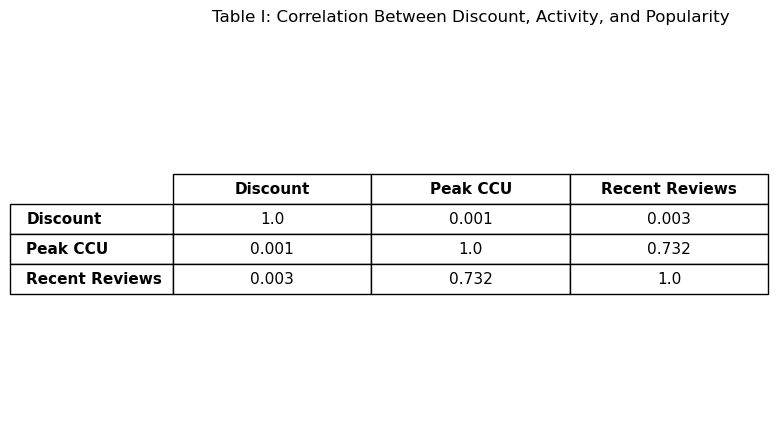

C:\Users\hites\AppData\Local\Temp\ipykernel_40528\3376407181.py:56: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_table = rq2.groupby('discount_group')[['peak_ccu','num_reviews_recent']].mean()


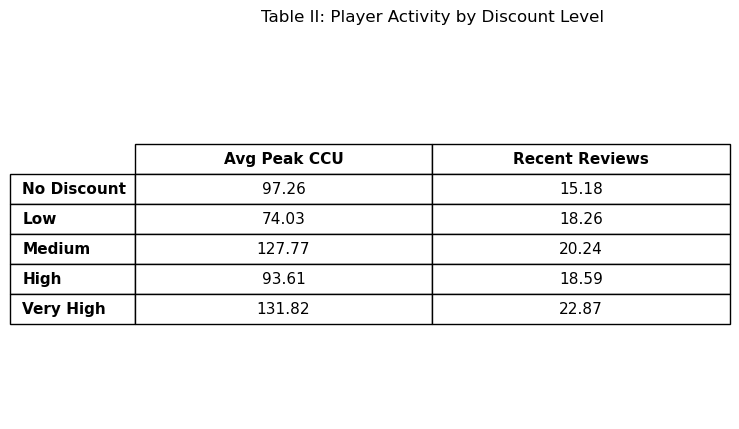

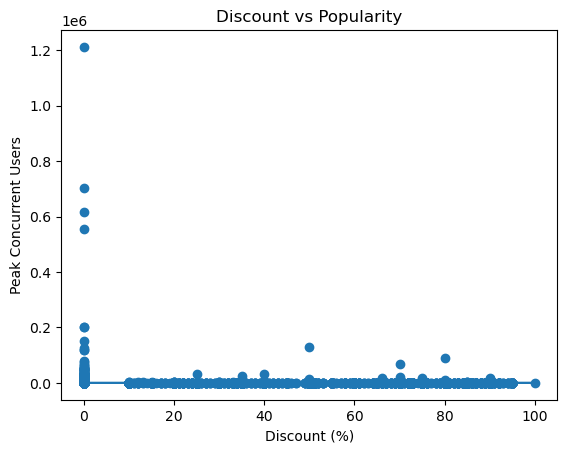

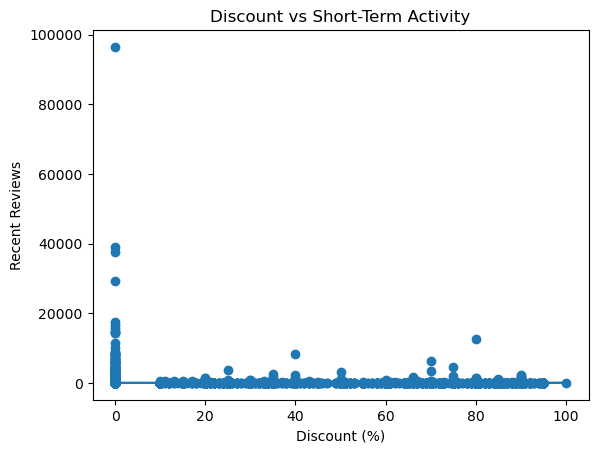

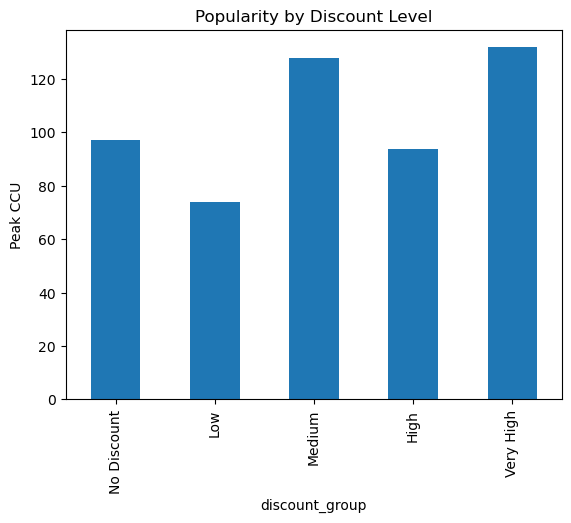

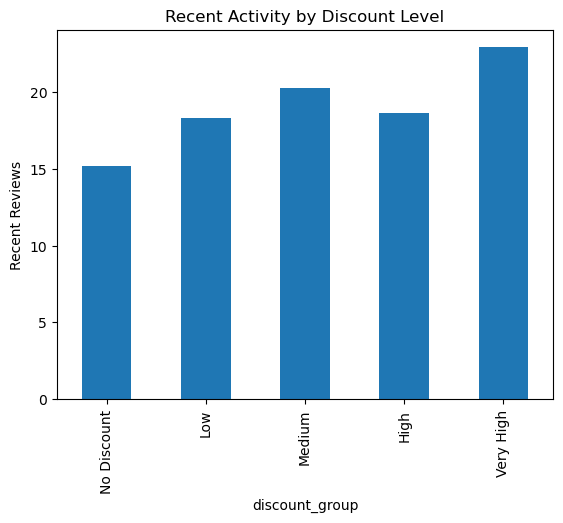

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset (local + Kaggle compatible)
try:
    df = pd.read_csv('games_march2025_cleaned.csv')
except:
    df = pd.read_csv('/kaggle/input/steam-games-dataset/games_march2025_cleaned.csv')

df = df.drop_duplicates()

# SELECT VARIABLES
rq2 = df[['discount', 'peak_ccu', 'num_reviews_recent']].dropna()


# CREATE DISCOUNT GROUPS

rq2['discount_group'] = pd.cut(
    rq2['discount'],
    bins=[-1, 0, 25, 50, 75, 100],
    labels=['No Discount', 'Low', 'Medium', 'High', 'Very High']
)


# TABLE 1: CORRELATION (PNG)

corr_table = rq2[['discount','peak_ccu','num_reviews_recent']].corr()

fig, ax = plt.subplots()
ax.axis('tight')
ax.axis('off')

table = ax.table(
    cellText=np.round(corr_table.values, 3),
    colLabels=['Discount', 'Peak CCU', 'Recent Reviews'],
    rowLabels=['Discount', 'Peak CCU', 'Recent Reviews'],
    cellLoc='center',
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.8)

for (row, col), cell in table.get_celld().items():
    if row == 0 or col == -1:
        cell.set_text_props(weight='bold')

plt.title('Table I: Correlation Between Discount, Activity, and Popularity', pad=20)
plt.savefig('RQ2_Correlation_Table.png', dpi=300, bbox_inches='tight')
plt.show()


# TABLE 2: GROUP SUMMARY (PNG)
group_table = rq2.groupby('discount_group')[['peak_ccu','num_reviews_recent']].mean()

fig, ax = plt.subplots()
ax.axis('tight')
ax.axis('off')

table = ax.table(
    cellText=np.round(group_table.values, 2),
    colLabels=['Avg Peak CCU', 'Recent Reviews'],
    rowLabels=group_table.index,
    cellLoc='center',
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.8)

for (row, col), cell in table.get_celld().items():
    if row == 0 or col == -1:
        cell.set_text_props(weight='bold')

plt.title('Table II: Player Activity by Discount Level', pad=20)
plt.savefig('RQ2_Group_Table.png', dpi=300, bbox_inches='tight')
plt.show()


# FIGURE 1: Discount vs Peak CCU (WITH TREND LINE)

plt.figure()
plt.scatter(rq2['discount'], rq2['peak_ccu'])

# Trend line
z = np.polyfit(rq2['discount'], rq2['peak_ccu'], 1)
p = np.poly1d(z)
plt.plot(rq2['discount'], p(rq2['discount']))

plt.xlabel('Discount (%)')
plt.ylabel('Peak Concurrent Users')
plt.title('Discount vs Popularity')
plt.savefig('RQ2_Discount_vs_PeakCCU.png', dpi=300, bbox_inches='tight')
plt.show()


# FIGURE 2: Discount vs Reviews (WITH TREND LINE)

plt.figure()
plt.scatter(rq2['discount'], rq2['num_reviews_recent'])

# Trend line
z = np.polyfit(rq2['discount'], rq2['num_reviews_recent'], 1)
p = np.poly1d(z)
plt.plot(rq2['discount'], p(rq2['discount']))

plt.xlabel('Discount (%)')
plt.ylabel('Recent Reviews')
plt.title('Discount vs Short-Term Activity')
plt.savefig('RQ2_Discount_vs_Reviews.png', dpi=300, bbox_inches='tight')
plt.show()

# FIGURE 3: Popularity by Discount Group
plt.figure()
group_table['peak_ccu'].plot(kind='bar')
plt.title('Popularity by Discount Level')
plt.ylabel('Peak CCU')
plt.savefig('RQ2_Popularity_by_Discount.png', dpi=300, bbox_inches='tight')
plt.show()


# FIGURE 4: Activity by Discount Group

plt.figure()
group_table['num_reviews_recent'].plot(kind='bar')
plt.title('Recent Activity by Discount Level')
plt.ylabel('Recent Reviews')
plt.savefig('RQ2_Activity_by_Discount.png', dpi=300, bbox_inches='tight')
plt.show()
